In [4]:
"""
LSTM-Autoencoder für mehrdimensionale Zeitreihen
================================================
Vollständiges, lauffähiges Beispiel mit PyTorch:

  1) Testdaten erzeugen (mehrdimensionale Zeitreihen)
  2) Architektur definieren (Encoder -> Bottleneck -> Decoder)
  3) Training mit Train/Validation-Split
  4) Modell speichern
  5) Trainingsqualität bewerten (Loss-Kurve + Rekonstruktionsfehler)

Ausführen:
    python lstm_autoencoder.py
"""

from __future__ import annotations
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("./autoencoder_output")
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# 1) TESTDATEN
# ============================================================
def generate_multivariate_series(
    n_samples: int = 1200,
    seq_len: int = 50,
    n_features: int = 3,
    noise: float = 0.1,
) -> np.ndarray:
    """
    Erzeugt Sequenzen mit einer bekannten niedrigdimensionalen Struktur:
    Jede Probe wird von zwei latenten Parametern (Frequenz, Phase) bestimmt,
    daraus werden 3 korrelierte Kanäle als Linearkombinationen gebildet.
    So kann der Autoencoder eine echte Kompression lernen.
    """
    t = np.linspace(0, 4 * np.pi, seq_len)
    data = np.zeros((n_samples, seq_len, n_features), dtype=np.float32)

    for i in range(n_samples):
        freq = np.random.uniform(0.5, 2.0)
        phase = np.random.uniform(0, 2 * np.pi)
        base = np.sin(freq * t + phase)

        data[i, :, 0] = base
        data[i, :, 1] = 0.7 * base + 0.3 * np.cos(freq * t + phase)
        data[i, :, 2] = -0.5 * base + 0.5 * np.sin(2 * freq * t)

    data += np.random.normal(0, noise, data.shape).astype(np.float32)
    return data


# ============================================================
# 2) ARCHITEKTUR
# ============================================================
class LSTMAutoencoder(nn.Module):
    """
    Encoder: LSTM verdichtet die Sequenz in einen versteckten Zustand,
             ein Linear-Layer projiziert diesen in den Bottleneck.
    Decoder: Bottleneck wird über die Sequenzlänge repliziert, eine
             zweite LSTM rekonstruiert die Zeitreihe Schritt für Schritt.
    """

    def __init__(
        self,
        n_features: int = 3,
        seq_len: int = 50,
        latent_dim: int = 8,
        hidden_dim: int = 32,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_lstm = nn.LSTM(n_features, hidden_dim, batch_first=True)
        self.encoder_fc = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        _, (h_n, _) = self.encoder_lstm(x)          # h_n: (1, batch, hidden)
        return self.encoder_fc(h_n.squeeze(0))       # (batch, latent_dim)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        repeated = self.decoder_fc(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        decoded, _ = self.decoder_lstm(repeated)
        return self.output_layer(decoded)            # (batch, seq_len, n_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))


# ============================================================
# 3) TRAINING
# ============================================================
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 30,
    lr: float = 1e-3,
) -> dict:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        # ---- Training ----
        model.train()
        train_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            recon = model(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.size(0)
        train_loss /= len(train_loader.dataset)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)
                recon = model(batch)
                val_loss += criterion(recon, batch).item() * batch.size(0)
        val_loss /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch:3d} | train={train_loss:.5f} | val={val_loss:.5f}")

    return history


# ============================================================
# 4) + 5) SPEICHERN UND BEWERTEN
# ============================================================
def evaluate_and_save(
    model: nn.Module,
    test_loader: DataLoader,
    history: dict,
) -> dict:
    # Rekonstruktionsfehler pro Testprobe
    model.eval()
    errors = []
    with torch.no_grad():
        for (batch,) in test_loader:
            batch = batch.to(DEVICE)
            recon = model(batch)
            mse = ((recon - batch) ** 2).mean(dim=(1, 2)).cpu().numpy()
            errors.extend(mse.tolist())
    errors = np.array(errors)

    metrics = {
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "test_mse_mean": float(errors.mean()),
        "test_mse_std": float(errors.std()),
        "test_mse_p95": float(np.percentile(errors, 95)),
    }

    print("\n=== Bewertung der Trainingsqualität ===")
    for k, v in metrics.items():
        print(f"{k:20s}: {v:.6f}")

    # --- Modell speichern ---
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": {
                "n_features": model.n_features,
                "seq_len": model.seq_len,
                "latent_dim": model.latent_dim,
            },
        },
        OUTPUT_DIR / "autoencoder.pt",
    )

    # --- Loss-Kurve ---
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Training")
    plt.plot(history["val_loss"], label="Validierung")
    plt.xlabel("Epoche")
    plt.ylabel("MSE-Loss")
    plt.title("Trainingsverlauf")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=120)
    plt.close()

    # --- Histogramm der Rekonstruktionsfehler ---
    plt.figure(figsize=(8, 4))
    plt.hist(errors, bins=40, edgecolor="black", alpha=0.75)
    plt.xlabel("Rekonstruktions-MSE pro Testprobe")
    plt.ylabel("Anzahl")
    plt.title("Verteilung der Rekonstruktionsfehler (Testset)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "reconstruction_errors.png", dpi=120)
    plt.close()

    # --- Metriken als JSON ---
    with open(OUTPUT_DIR / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    return metrics


# ============================================================
# MAIN
# ============================================================
def main() -> None:
    # 1) Daten
    data = generate_multivariate_series(n_samples=1200, seq_len=50, n_features=3)
    train, val, test = data[:800], data[800:1000], data[1000:]

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(train)), batch_size=32, shuffle=True
    )
    val_loader = DataLoader(TensorDataset(torch.from_numpy(val)), batch_size=32)
    test_loader = DataLoader(TensorDataset(torch.from_numpy(test)), batch_size=32)

    # 2) Modell
    model = LSTMAutoencoder(
        n_features=3, seq_len=50, latent_dim=8, hidden_dim=32
    ).to(DEVICE)
    print(model)
    print(f"Parameter: {sum(p.numel() for p in model.parameters())}")
    print(f"Device: {DEVICE}\n")

    # 3) Training
    history = train_model(model, train_loader, val_loader, epochs=30, lr=1e-3)

    # 4 + 5) Speichern und bewerten
    evaluate_and_save(model, test_loader, history)
    print(f"\nArtefakte gespeichert in: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()

LSTMAutoencoder(
  (encoder_lstm): LSTM(3, 32, batch_first=True)
  (encoder_fc): Linear(in_features=32, out_features=8, bias=True)
  (decoder_fc): Linear(in_features=8, out_features=32, bias=True)
  (decoder_lstm): LSTM(32, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=3, bias=True)
)
Parameter: 13835
Device: cpu

Epoch   1 | train=0.36288 | val=0.35606
Epoch   2 | train=0.35662 | val=0.35416
Epoch   3 | train=0.35525 | val=0.35350
Epoch   4 | train=0.35462 | val=0.35257
Epoch   5 | train=0.35359 | val=0.35143
Epoch   6 | train=0.35237 | val=0.34987
Epoch   7 | train=0.34783 | val=0.34116
Epoch   8 | train=0.33653 | val=0.33488
Epoch   9 | train=0.33159 | val=0.32830
Epoch  10 | train=0.32460 | val=0.32493
Epoch  11 | train=0.32047 | val=0.32578
Epoch  12 | train=0.32143 | val=0.31903
Epoch  13 | train=0.32499 | val=0.33555
Epoch  14 | train=0.33216 | val=0.32287
Epoch  15 | train=0.32278 | val=0.31237
Epoch  16 | train=0.31424 | val=0.30476
Epoch  17 | tr

In [6]:
"""
LSTM-Autoencoder für mehrdimensionale Zeitreihen
================================================
Vollständiges, lauffähiges Beispiel mit PyTorch:

  1) Testdaten erzeugen (mehrdimensionale Zeitreihen)
  2) Architektur definieren (Encoder -> Bottleneck -> Decoder)
  3) Training mit Train/Validation-Split
  4) Modell speichern
  5) Trainingsqualität bewerten:
       - Loss-Kurve, Rekonstruktionsfehler-Histogramm
       - Overfitting-, Konvergenz- und Baseline-Analyse
       - Original vs. Rekonstruktion (visuell)
       - PCA-Projektion des latenten Raums
       - Textreport mit qualitativer Bewertung

Ausführen:
    python lstm_autoencoder.py
"""

from __future__ import annotations
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("./autoencoder_output")
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# 1) TESTDATEN
# ============================================================
def generate_multivariate_series(
    n_samples: int = 1200,
    seq_len: int = 50,
    n_features: int = 3,
    noise: float = 0.1,
) -> np.ndarray:
    """
    Erzeugt Sequenzen mit einer bekannten niedrigdimensionalen Struktur:
    Jede Probe wird von zwei latenten Parametern (Frequenz, Phase) bestimmt,
    daraus werden 3 korrelierte Kanäle als Linearkombinationen gebildet.
    So kann der Autoencoder eine echte Kompression lernen.
    """
    t = np.linspace(0, 4 * np.pi, seq_len)
    data = np.zeros((n_samples, seq_len, n_features), dtype=np.float32)

    for i in range(n_samples):
        freq = np.random.uniform(0.5, 2.0)
        phase = np.random.uniform(0, 2 * np.pi)
        base = np.sin(freq * t + phase)

        data[i, :, 0] = base
        data[i, :, 1] = 0.7 * base + 0.3 * np.cos(freq * t + phase)
        data[i, :, 2] = -0.5 * base + 0.5 * np.sin(2 * freq * t)

    data += np.random.normal(0, noise, data.shape).astype(np.float32)
    return data


# ============================================================
# 2) ARCHITEKTUR
# ============================================================
class LSTMAutoencoder(nn.Module):
    """
    Encoder: LSTM verdichtet die Sequenz in einen versteckten Zustand,
             ein Linear-Layer projiziert diesen in den Bottleneck.
    Decoder: Bottleneck wird über die Sequenzlänge repliziert, eine
             zweite LSTM rekonstruiert die Zeitreihe Schritt für Schritt.
    """

    def __init__(
        self,
        n_features: int = 3,
        seq_len: int = 50,
        latent_dim: int = 8,
        hidden_dim: int = 32,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_lstm = nn.LSTM(n_features, hidden_dim, batch_first=True)
        self.encoder_fc = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        _, (h_n, _) = self.encoder_lstm(x)          # h_n: (1, batch, hidden)
        return self.encoder_fc(h_n.squeeze(0))       # (batch, latent_dim)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        repeated = self.decoder_fc(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        decoded, _ = self.decoder_lstm(repeated)
        return self.output_layer(decoded)            # (batch, seq_len, n_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))


# ============================================================
# 3) TRAINING
# ============================================================
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 30,
    lr: float = 1e-3,
) -> dict:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        # ---- Training ----
        model.train()
        train_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            recon = model(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.size(0)
        train_loss /= len(train_loader.dataset)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)
                recon = model(batch)
                val_loss += criterion(recon, batch).item() * batch.size(0)
        val_loss /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch:3d} | train={train_loss:.5f} | val={val_loss:.5f}")

    return history


# ============================================================
# 4) + 5) SPEICHERN UND BEWERTEN
# ============================================================
def evaluate_and_save(
    model: nn.Module,
    test_loader: DataLoader,
    history: dict,
) -> dict:
    # Rekonstruktionsfehler pro Testprobe
    model.eval()
    errors = []
    with torch.no_grad():
        for (batch,) in test_loader:
            batch = batch.to(DEVICE)
            recon = model(batch)
            mse = ((recon - batch) ** 2).mean(dim=(1, 2)).cpu().numpy()
            errors.extend(mse.tolist())
    errors = np.array(errors)

    metrics = {
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "test_mse_mean": float(errors.mean()),
        "test_mse_std": float(errors.std()),
        "test_mse_p95": float(np.percentile(errors, 95)),
    }

    print("\n=== Bewertung der Trainingsqualität ===")
    for k, v in metrics.items():
        print(f"{k:20s}: {v:.6f}")

    # --- Modell speichern ---
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": {
                "n_features": model.n_features,
                "seq_len": model.seq_len,
                "latent_dim": model.latent_dim,
            },
        },
        OUTPUT_DIR / "autoencoder.pt",
    )

    # --- Loss-Kurve ---
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Training")
    plt.plot(history["val_loss"], label="Validierung")
    plt.xlabel("Epoche")
    plt.ylabel("MSE-Loss")
    plt.title("Trainingsverlauf")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=120)
    plt.close()

    # --- Histogramm der Rekonstruktionsfehler ---
    plt.figure(figsize=(8, 4))
    plt.hist(errors, bins=40, edgecolor="black", alpha=0.75)
    plt.xlabel("Rekonstruktions-MSE pro Testprobe")
    plt.ylabel("Anzahl")
    plt.title("Verteilung der Rekonstruktionsfehler (Testset)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "reconstruction_errors.png", dpi=120)
    plt.close()

    # --- Metriken als JSON ---
    with open(OUTPUT_DIR / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    return metrics


# ============================================================
# ZUSATZ: DETAILLIERTE BEWERTUNG DES TRAININGS
# ============================================================
def _collect_reconstructions(model: nn.Module, loader: DataLoader):
    """Sammelt Originale und Rekonstruktionen als NumPy-Arrays."""
    model.eval()
    originals, recons = [], []
    with torch.no_grad():
        for (batch,) in loader:
            batch_dev = batch.to(DEVICE)
            recon = model(batch_dev).cpu()
            originals.append(batch)
            recons.append(recon)
    return torch.cat(originals).numpy(), torch.cat(recons).numpy()


def _baseline_mse(data: np.ndarray) -> float:
    """Triviale Baseline: konstant den Mittelwert pro Kanal vorhersagen."""
    mean_per_channel = data.mean(axis=(0, 1), keepdims=True)
    return float(((data - mean_per_channel) ** 2).mean())


def _verdict(good: bool, ok: bool) -> str:
    return "gut" if good else ("okay" if ok else "problematisch")


def assess_training_quality(
    model: nn.Module,
    test_loader: DataLoader,
    history: dict,
) -> dict:
    """
    Erzeugt eine strukturierte Bewertung des Trainings.

    Prüft drei Dimensionen:
      A) Overfitting: Verhältnis Val/Train-Loss am Ende
      B) Konvergenz:  Stabilität der letzten Epochen
      C) Rekonstruktionsqualität: Explained Variance und Vergleich
         mit einer Mittelwert-Baseline
    """
    originals, recons = _collect_reconstructions(model, test_loader)

    # A) Overfitting
    train_final = history["train_loss"][-1]
    val_final = history["val_loss"][-1]
    overfit_ratio = val_final / max(train_final, 1e-12)

    # B) Konvergenz: relative Streuung der letzten 5 Val-Losses
    tail = history["val_loss"][-5:]
    stability = float(np.std(tail) / (np.mean(tail) + 1e-12))

    # C) Rekonstruktionsqualität
    total_var = float(originals.var())
    residual_var = float((originals - recons).var())
    explained_variance = 1.0 - residual_var / (total_var + 1e-12)

    model_mse = float(((originals - recons) ** 2).mean())
    baseline_mse = _baseline_mse(originals)
    improvement = 1.0 - model_mse / baseline_mse

    per_channel_mse = ((originals - recons) ** 2).mean(axis=(0, 1)).tolist()

    assessment = {
        "overfitting": {
            "train_loss_final": train_final,
            "val_loss_final": val_final,
            "ratio_val_train": overfit_ratio,
            "verdict": _verdict(overfit_ratio < 1.2, overfit_ratio < 1.5),
        },
        "convergence": {
            "val_loss_std_last5": float(np.std(tail)),
            "relative_stability": stability,
            "verdict": _verdict(stability < 0.05, stability < 0.10),
        },
        "reconstruction_quality": {
            "explained_variance": float(explained_variance),
            "model_mse": model_mse,
            "baseline_mse": baseline_mse,
            "improvement_over_baseline": float(improvement),
            "verdict": _verdict(explained_variance > 0.9, explained_variance > 0.7),
        },
        "per_channel_mse": per_channel_mse,
    }

    # Textreport
    print("\n" + "=" * 62)
    print("BEWERTUNG DES TRAININGS")
    print("=" * 62)

    o = assessment["overfitting"]
    print(f"\n[A] Overfitting  ->  {o['verdict'].upper()}")
    print(f"    train_loss_final = {o['train_loss_final']:.5f}")
    print(f"    val_loss_final   = {o['val_loss_final']:.5f}")
    print(f"    Val/Train Ratio  = {o['ratio_val_train']:.3f}   "
          "(<1.2 gut, >1.5 Overfitting)")

    c = assessment["convergence"]
    print(f"\n[B] Konvergenz  ->  {c['verdict'].upper()}")
    print(f"    Rel. Stabilität (letzte 5 Epochen) = {c['relative_stability']:.4f}   "
          "(<0.05 stabil)")

    r = assessment["reconstruction_quality"]
    print(f"\n[C] Rekonstruktionsqualität  ->  {r['verdict'].upper()}")
    print(f"    Explained Variance        = {r['explained_variance'] * 100:6.2f}%")
    print(f"    Modell-MSE                = {r['model_mse']:.5f}")
    print(f"    Baseline-MSE (Mittelwert) = {r['baseline_mse']:.5f}")
    print(f"    Verbesserung ggü. Baseline= {r['improvement_over_baseline'] * 100:6.2f}%")

    print(f"\n    MSE pro Kanal:")
    for i, mse in enumerate(per_channel_mse):
        print(f"      Kanal {i}: {mse:.5f}")
    print("=" * 62)

    return assessment


def plot_reconstructions(
    model: nn.Module,
    test_loader: DataLoader,
    n_samples: int = 4,
) -> None:
    """Original vs. Rekonstruktion für n Testproben (qualitativer Check)."""
    model.eval()
    batch = next(iter(test_loader))[0][:n_samples].to(DEVICE)
    with torch.no_grad():
        recon = model(batch).cpu().numpy()
    original = batch.cpu().numpy()

    n_features = original.shape[2]
    fig, axes = plt.subplots(
        n_samples, n_features,
        figsize=(3.5 * n_features, 2.2 * n_samples),
        squeeze=False,
    )
    for i in range(n_samples):
        for j in range(n_features):
            ax = axes[i, j]
            ax.plot(original[i, :, j], label="Original", linewidth=1.4)
            ax.plot(recon[i, :, j], label="Rekonstruktion",
                    linewidth=1.4, linestyle="--")
            ax.set_title(f"Probe {i + 1}, Kanal {j}", fontsize=9)
            ax.grid(alpha=0.3)
            if i == 0 and j == 0:
                ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "reconstructions.png", dpi=120)
    plt.close()


def plot_latent_space(model: nn.Module, test_loader: DataLoader) -> None:
    """
    2D-PCA-Projektion des latenten Raums.
    Sinnvoll strukturierte Cluster/Kontinua deuten darauf hin, dass
    der Bottleneck echte Faktoren der Daten erfasst hat.
    """
    model.eval()
    latents = []
    with torch.no_grad():
        for (batch,) in test_loader:
            z = model.encode(batch.to(DEVICE)).cpu().numpy()
            latents.append(z)
    Z = np.concatenate(latents, axis=0)          # (n, latent_dim)

    # PCA via SVD (spart die sklearn-Abhängigkeit)
    Zc = Z - Z.mean(axis=0)
    _, s, Vt = np.linalg.svd(Zc, full_matrices=False)
    Z2 = Zc @ Vt[:2].T
    var_ratio = (s ** 2) / (s ** 2).sum()

    plt.figure(figsize=(6, 5))
    plt.scatter(Z2[:, 0], Z2[:, 1], s=16, alpha=0.6)
    plt.xlabel(f"PC1 ({var_ratio[0] * 100:.1f}%)")
    plt.ylabel(f"PC2 ({var_ratio[1] * 100:.1f}%)")
    plt.title("Latenter Raum – PCA-Projektion")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "latent_space.png", dpi=120)
    plt.close()


# ============================================================
# MAIN
# ============================================================
def main() -> None:
    # 1) Daten
    data = generate_multivariate_series(n_samples=1200, seq_len=50, n_features=3)
    train, val, test = data[:800], data[800:1000], data[1000:]

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(train)), batch_size=32, shuffle=True
    )
    val_loader = DataLoader(TensorDataset(torch.from_numpy(val)), batch_size=32)
    test_loader = DataLoader(TensorDataset(torch.from_numpy(test)), batch_size=32)

    # 2) Modell
    model = LSTMAutoencoder(
        n_features=3, seq_len=50, latent_dim=8, hidden_dim=32
    ).to(DEVICE)
    print(model)
    print(f"Parameter: {sum(p.numel() for p in model.parameters())}")
    print(f"Device: {DEVICE}\n")

    # 3) Training
    history = train_model(model, train_loader, val_loader, epochs=100, lr=1e-3)

    # 4 + 5) Speichern und bewerten (Basis-Metriken + Plots)
    evaluate_and_save(model, test_loader, history)

    # 5b) Detaillierte Trainingsbewertung
    assessment = assess_training_quality(model, test_loader, history)
    plot_reconstructions(model, test_loader, n_samples=4)
    plot_latent_space(model, test_loader)

    with open(OUTPUT_DIR / "training_assessment.json", "w") as f:
        json.dump(assessment, f, indent=2)

    print(f"\nArtefakte gespeichert in: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()

LSTMAutoencoder(
  (encoder_lstm): LSTM(3, 32, batch_first=True)
  (encoder_fc): Linear(in_features=32, out_features=8, bias=True)
  (decoder_fc): Linear(in_features=8, out_features=32, bias=True)
  (decoder_lstm): LSTM(32, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=3, bias=True)
)
Parameter: 13835
Device: cpu

Epoch   1 | train=0.36288 | val=0.35606
Epoch   2 | train=0.35662 | val=0.35416
Epoch   3 | train=0.35525 | val=0.35350
Epoch   4 | train=0.35462 | val=0.35257
Epoch   5 | train=0.35359 | val=0.35143
Epoch   6 | train=0.35237 | val=0.34987
Epoch   7 | train=0.34783 | val=0.34116
Epoch   8 | train=0.33653 | val=0.33488
Epoch   9 | train=0.33159 | val=0.32830
Epoch  10 | train=0.32460 | val=0.32493
Epoch  11 | train=0.32047 | val=0.32578
Epoch  12 | train=0.32143 | val=0.31903
Epoch  13 | train=0.32499 | val=0.33555
Epoch  14 | train=0.33216 | val=0.32287
Epoch  15 | train=0.32278 | val=0.31237
Epoch  16 | train=0.31424 | val=0.30476
Epoch  17 | tr

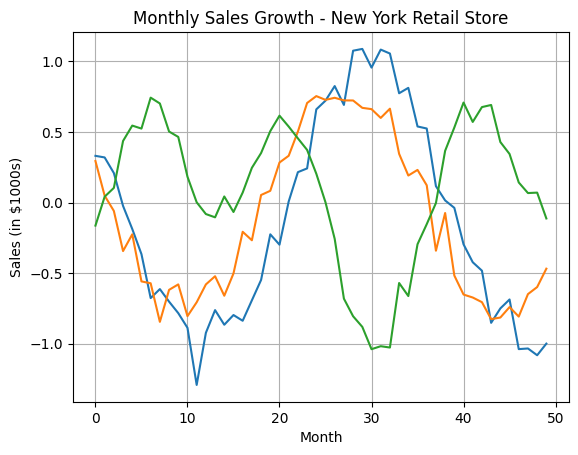

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Monthly sales data (in thousands of dollars)
sales = generate_multivariate_series()[0]

# Plotting the sales data
plt.plot(sales)
plt.title('Monthly Sales Growth - New York Retail Store')
plt.xlabel('Month')
plt.ylabel('Sales (in $1000s)')
plt.grid(True)
plt.show()